In [1]:
if 'google.colab' in str(get_ipython()):
    from google.colab import drive
    
    drive.mount('/content/drive', force_remount=True)
    !cp drive/MyDrive/*.pkl drive/MyDrive/*.npy drive/MyDrive/validation.py .

Mounted at /content/drive


In [2]:
import validation

# Homework Assignment 1

#### Name and source statement
Enter your name (in the requested format, please) and your github handle. Also add a statement on your sources. You are allowed to look up things and use AI tools, but you need to honestly state what you used and how, e.g. to debug code and resolve errors, conceptual understanding, or code cleanup or optimization. This is required, don't forget. 

In [3]:
# Fill in your name using the given format, GitHub handle, and sources
your_name = "ZANOTTI, TOMMASO"
github_handle = "TomZanna"
statement = """
            Gemini to setup my dev environment (VSCode + Colab extension).
            Github Copilot Free to debug and cleanup code for question 2.1
            """

##### **Tips on using AI tools**
From experiences over the last years in this and other courses, we learned that the quality of assignment solutions has (somewhat surprisingly) gone down with the arrival of AI tools. This is in part because chatbots may not fully understand the question and thus make mistakes, but primarily because AI tools cause students to interact less with each other, and more often postpone work too long. Recommendations:
* Using AI can help you do better ML engineering, but requires solid ML knowledge and programming skills to begin with to critically assess the responses. Make sure you understand the concepts taught in the course and do the labs first.
* Talk to fellow students (and the teaching team). Don't copy code but do ask questions and learn from each other. Share the enthusiasm of learning and solving problems.
* Always try to solve the assignment by yourself so that you really understand the question and the challenges. Using AI to understand and resolve errors, or to explain vague concepts is fine.


# Topic: Ancient Eritrean languages

In this assignment, we use machine learning to recognize handwritten text from a dataset that combines the Vai, Osmanya, and N’Ko scripts. These scripts originate from West Africa and are used to represent different indigenous languages, each with its own distinct writing system and historical context. Due to limited digital resources and the visual complexity of handwritten characters, automatic recognition of these scripts remains challenging. To address this, we apply machine learning techniques to identify handwritten characters and map them to their corresponding modern digital representations.

The dataset that we will use contains scanned 28-by-28 pixel images of numbers from 1-10.

Important note: While the numbers are indexed from 0-9 to maintain compatibility, these languages do not have a 0. Their number 10 has therefore been mapped to label 0. In this code it does not matter, but please keep it in mind.

<img src="./images/geez.png">

This [dataset](https://openml.org/d/47158) consists of 180k images (28x28 pixels) of 10 characters from the Vai, Osmanya, and N’Ko scripts. Of course there are more characters but we'll keep things simple for this homework. You can read more about the construction of this dataset in [this paper](https://arxiv.org/pdf/2009.13509).



In [4]:
# For use in colab
if 'google.colab' in str(get_ipython()):
  !pip install openml --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.8/93.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 38.4 MB/s eta 0:00:0000:01


In [5]:
# Optional: uncomment the following line to run in Google Colab
# This will link the notebook to your own Google drive to store your models and cache the dataset.
# It will ask you to click on a link to get a verification code.
# When done, you can click the folder icon on the left and see your drive.
# from google.colab import drive
# import gdown
# drive.mount('/content/drive', force_remount=True)

In [6]:
# imports
#import tensorflow
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openml
import time
import math
import tqdm
import pickle
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from tqdm import tqdm
import pickle

%matplotlib inline

# Pre-flight checklist. Do not change this code.
# Make sure that you have installed recent versions of key packages.
from packaging import version
import sklearn
sklearn_version = sklearn.__version__
if version.parse(sklearn_version) < version.parse("1.6.0"):
    print("scikit-learn is outdated: {}. Please update now! pip install -U scikit-learn".format(sklearn_version))
else:
    print("OK. You may continue :)")

# Hide convergence warning for now
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.simplefilter(action="ignore", category=ConvergenceWarning)

OK. You may continue :)


In [7]:
import joblib

# YOLO
joblib.parallel_config(n_jobs=-1).__enter__()

{'backend': default(None),
 'n_jobs': -1,
 'verbose': default(0),
 'temp_folder': default(None),
 'max_nbytes': default('1M'),
 'mmap_mode': default('r'),
 'prefer': default(None),
 'require': default(None)}

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Loading Language data from OpenML. This may take a bit longer the first time you download it.
# Don't overwrite the X, X_eval and y, y_eval variables anywhere in this notebook.
# Seriously, don't.

data = openml.datasets.get_dataset(dataset_id=47160)
lang_X, lang_y, _, _ = data.get_data(target="labels")

# Scaling to [0..1]. Logistic Regression can be sensitive to scale
# We also tried standard scaling, but the results were very similar.
lang_X_scaled = lang_X / 255.0

# Split the data, using 25% for training and 25% for testing (in the interest of time/resources)
X, X_eval, y, y_eval = train_test_split(lang_X_scaled, lang_y, stratify=lang_y, train_size=0.10, test_size=0.10, random_state=0)

# A sorted list of all labels. Uses the order used in the original dataset
labels = sorted([label for label in set(lang_y)])

# Mapping of classes to lang characters
lang_classes = {0:"zero", 1: "one", 2: "two", 3: "three", 4: "four", 5: "five",
                     6: "six", 7: "seven", 8: "eight", 9: "nine"}
y_classes = np.array([lang_classes[int(yi)] for yi in y])

In [9]:
# Plotting helper functions. Don't edit these.
%matplotlib inline
from IPython import display
from tqdm.auto import tqdm
from sklearn.exceptions import ConvergenceWarning
from sklearn.utils._testing import ignore_warnings

@ignore_warnings(category=ConvergenceWarning)
def plot_live(X, y, evaluator, param_name, param_range, scale='log', ylim=(0,1), ylabel='score', marker = '.'):
    """ Renders a plot that updates with every evaluation from the evaluator.
    Keyword arguments:
    X -- the data for training and testing
    y -- the correct labels
    evaluator -- a function with signature (X, y, param_value) that returns a dictionary of scores.
                 Examples: {"train": 0.9, "test": 0.95} or {"model_1": 0.9, "model_2": 0.7}
    param_name -- the parameter that is being varied on the X axis. Can be a hyperparameter, sample size,...
    param_range -- list of all possible values on the x-axis
    scale -- defines which scale to plot the x-axis on, either 'log' (logarithmic) or 'linear'
    ylim -- tuple with the lowest and highest y-value to plot (e.g. (0, 1))
    ylabel -- the y-axis title
    """
    # Plot interactively
    plt.ion()
    plt.ylabel(ylabel)
    plt.xlabel(param_name)

    # Make the scale look nice
    plt.xscale(scale)
    plt.xlim(param_range[0],param_range[-1])
    plt.ylim(ylim)
    plt.grid(True)

    # Start from empty plot, then fill it
    series = {}
    lines = {}
    xvals = []
    for i in tqdm(param_range):
        scores = evaluator(X, y, i)
        xvals.append(i)
        if not series:  # This checks if series dictionary is empty, meaning it's the first iteration
            for k in scores.keys():
                series[k] = [scores[k]]  # Initialize series with the first score
                lines[k], = plt.plot(xvals, series[k], marker=marker, label=k)  # Plot the initial point
        else:
            for k in scores.keys():
                series[k].append(scores[k])
                lines[k].set_data(xvals, series[k])

        # refresh plot
        plt.legend(loc='best')
        plt.margins(0.1)
        display.display(plt.gcf())
        display.clear_output(wait=True)

# Plots data instances as 28x28 images
def plot_examples(images, labels, row_length=7, title=""):
    nr_rows = math.ceil(len(images) / row_length)
    fig, axes = plt.subplots(nr_rows, row_length, figsize=(row_length, 1.1 * nr_rows))
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    for i, (index, row) in enumerate(images.iterrows()):
        axes[i].imshow(row.values.reshape(28, 28), cmap='gray_r')
        if labels is not None:
            axes[i].set_xlabel(lang_classes[int(labels.loc[index])])
        axes[i].set_xticks(())
        axes[i].set_yticks(())

    # Turn off any extra subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')

    fig.suptitle(title)
    plt.show()

### Peeking at the data
If we plot the characters, we see that there is quite some variation. The same
number can be written in quite different ways.

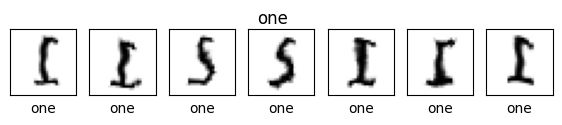

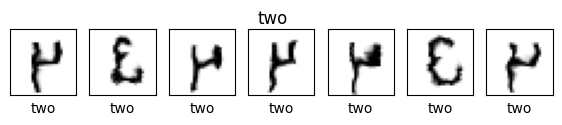

In [10]:
# Gets indices of examples with the given class
num_ex = 7
def y_class(c, num_ex):
    return y[y == c].index.values.tolist()[:num_ex]

for label in labels[1:3]:
    indices = y_class(label, num_ex)
    plot_examples(X.loc[indices], y.loc[indices], row_length=num_ex, title=lang_classes[int(label)])

## Pixels vs Embeddings
Given the high variability in the way characters are written, pixel values may not be the best representation for linear models. We can instead use a (pretrained) deep learning model to extract a better vector representation (an embedding) of the images. Then, we can use these features (instead of the pixel values) as input for your linear model. As we will see later in the course, such representations are robust against changes in the exact position of the letters (translation invariance) and can identify small and larger patterns (from lines and curves to entire letters), which helps when characters have similar sub-curves but aren't exactly the same.

<img src="https://qdrant.tech/articles_data/what-are-embeddings/How-Embeddings-Work.jpg" width=800 />

Below we provide code to create such embeddings, using a MobileNet architecture pretrained on ImageNet. You don't need to fully understand this code yet, but you'll be expected to understand and write code like this by the end of the course. To save unnecessary compute (and issues with GPUs) we have already included the embedded data in your assignment repo, and will load it now.

**Optional**: you can always rerun the code out of interest (uncomment the lines below). We do recommend using a GPU for this (in Colab, change your Runtime to a GPU Runtime, T4 is fine). If you're already familiar with deep learning architectures, we recommend reading [the MobileNet v2 paper](https://arxiv.org/abs/1801.04381).

In [11]:

# Check for GPU availability (MPS for Mac, CUDA for Nvidia, else CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Used device: mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Used device: cuda")
else:
    device = torch.device("cpu")
    print("Used device: cpu")

# Class to define an image dataset that applies transformations on the fly
class ImageDataset(Dataset):
    def __init__(self, tensors, transform=None):
        self.tensors = tensors
        self.transform = transform
        
    def __getitem__(self, index):
        x = self.tensors[index]
        if self.transform:
            x = self.transform(x)
        return x
        
    def __len__(self):
        return len(self.tensors)

# Class that computes MobileNetV2 embeddings for a given dataset
def create_embedding(X, batch_size=32):
    # --- 1. Data Preparation ---
    
    # Scale back to [0, 255] (to correctly apply the MobileNet model later)
    X = X * 255.0 

    if isinstance(X, pd.DataFrame):
        X = X.to_numpy()
        
    # Reshape flattened vectors (N, 784) -> (N, 28, 28)
    # Ensure type is uint8 for image processing or float32 for model
    X = X.reshape(-1, 28, 28).astype(np.uint8)
    
    # Convert to Tensor
    tensor_x = torch.from_numpy(X).float() # Shape: (N, 28, 28)

    # --- 2. Define Transforms ---
    # We need to resize to 96x96 to apply MobileNet and duplicate channels to create RGB.
    
    preprocess = transforms.Compose([
        transforms.ToPILImage(),             # Convert tensor/array to PIL Image for resizing
        transforms.Resize((96, 96)),         # Resize to 96x96
        transforms.Grayscale(num_output_channels=3), # Duplicate channels (1 -> 3)
        transforms.ToTensor(),               # Convert to Tensor (0-1 scale)
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Scale to [-1, 1]
    ])

    # --- 3. Model Setup ---
    # Load MobileNetV2 with ImageNet weights
    # 'weights' parameter is the new standard (replaces 'pretrained=True')
    weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
    model = models.mobilenet_v2(weights=weights)
    
    # Modify the classifier to act as a feature extractor (Global Average Pooling)
    # In PyTorch, MobileNetV2's features end before the classifier. 
    # We just need to remove the final classification layer.
    model.classifier = nn.Identity() 
    
    model.to(device)
    model.eval() # Set to evaluation mode (disables Dropout/BatchNorm updates)

    # --- 4. Processing Loop ---
    all_embeddings = []

    dataset = ImageDataset(tensor_x, transform=preprocess)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    with torch.no_grad(): # Disable gradient calculation for inference
        for batch in tqdm(loader):
            batch = batch.to(device)
            
            # Forward pass
            # MobileNetV2 features output shape is (Batch, 1280, 3, 3) for 96x96 input
            # We need to pool it. The original code used pooling='avg'.
            features = model.features(batch) 
            
            # Apply Global Average Pooling: (Batch, 1280, 3, 3) -> (Batch, 1280)
            pooled_features = torch.nn.functional.adaptive_avg_pool2d(features, (1, 1))
            pooled_features = torch.flatten(pooled_features, 1)
            
            all_embeddings.append(pooled_features.cpu().numpy())

    return np.vstack(all_embeddings)

# --- Usage --- 
# This part is entirely optional.
# Only uncomment if you want to experiment with embeddings. Be aware that it will take a while to run on CPU.
# Make sure that you use the embeddings that we provided for the remainder of the assignment.
# X_embedded = create_embedding(X)
# X_eval_embedded = create_embedding(X_eval)

# with open('X_emb_train.pkl', 'wb') as f:
#    pickle.dump(X_embedded, f)
# with open('X_emb_test.pkl', 'wb') as f:
#    pickle.dump(X_eval_embedded, f)

Used device: cpu


In [12]:
# Loading the embedded data from disc

with open('X_emb_train.pkl', 'rb') as f:
    X_embedded = pickle.load(f)

with open('X_emb_test.pkl', 'rb') as f:
    X_eval_embedded = pickle.load(f)

We can visualize the embeddings using [t-SNE](https://lvdmaaten.github.io/tsne/), a dimensionality reduction method that helps to visualize the original high-dimensional embedding into a 2D scatterplot. From this we can see that the images of the same character are clustered together, which suggests that the embedding may be useful to distinguish them.

**Optional** You can run the code yourself by commenting out the call below. The image will look different but should still show clear clusters per character. You can also try other values for the 'perplexity' parameter. We commented it out (and show the plot) because computing t-SNE is quite expensive. 

<img src="./images/tsne.png" width=700 />

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne():
  # Perform t-SNE
  tsne = TSNE(n_components=2, perplexity=30, random_state=42)
  embeddings_2d = tsne.fit_transform(X_embedded)

  # Plot the t-SNE embedding
  plt.figure(figsize=(10, 8))
  y_numeric = y.astype(int)
  unique_labels = np.unique(y_numeric)
  cmap = plt.get_cmap('tab10')
  for label in unique_labels:
      indices = y_numeric == label
      plt.scatter(
          embeddings_2d[indices, 0], embeddings_2d[indices, 1],
          color=cmap(label), label=lang_classes[label], alpha=0.7
      )
  plt.xlabel("t-SNE Component 1")
  plt.ylabel("t-SNE Component 2")
  plt.title("t-SNE Visualization of Character Embeddings")
  plt.legend(title="Class Labels", loc="best")
  plt.savefig("tsne.png")

# OPTIONAL: Uncomment to re-create the TSNE plot
# Comment it out again before submitting (it will slow down evaluation)
# plot_tsne()

# Questions
Please solve the questions below. Notes:
* The questions can be done in any order, although subquestions (e.g. 1.1 and 1.2) build on each other.
* Every sub-question counts for 1 point and there are 10 points in total. During final grading, partial points are possible.
* Some questions are multiple choice. Indication all options will give you 0 points (but you can't get negative points on a question).
* Your code, output plots and the multiple-choice questions will all be graded. Make sure that everything (all outputs and all plots) are in your notebook when you submit it.

## Question 1

### Question 1.1: Model tuning (1 point)
Implement a method `evaluate_LR` that evaluates a Logistic Regression model trained with a given regularization constant (C), and the Limited-memory Broyden–Fletcher–Goldfarb–Shanno optimizer. It should return the train and test score of a 5-fold stratified cross-validation using the accuracy metric. You don't need to do any additional preprocessing of the data at this point. It is already scaled.

**Important:** Only use the variables passed as parameters (in this case, `X`, `y`, and `C`). Do not add additional parameters to the function, and do not use global variables in the function implementation (except for imported modules and functions, which you are free to use). These guidelines also apply to any future questions in this and future assignments.

Next, you need to find the optimal amount of regularization for this dataset. To do this, implement a method `plot_curve` that plots the training and test scores of `evaluate_LR` on a stratified subsample of size `train_size` on the Devanagari dataset, for C values ranging from at least 1e-4 (10<sup>-4</sup>) to 1e4 (10<sup>4</sup>) on a log base 10 scale, with at least 9 values. Use `random_state=0` for reproducibility. You should use the plotting function `plot_live` defined above (carefully read what it does - it will save you time!).

Tune C on a 25% subsample of the data to `evaluate_LR`. Using a subsample won't give you optimal performance, but when tuning hyperparameters (which is expensive) you can often get a pretty good estimate of the best hyperparameters by using a smaller sample. When you have a rough idea of where the good hyperparameters lie, you can evaluate these on a larger sample. This is also called multi-fidelty optimization. For now, using a 25% subsample of the training set is fine to optimize the C parameter is fine.

*note:* Throughout the notebook, you will find cells that call functions on the `validation` module. You can run these cells to perform a _very_ basic test on your provided answer. If validation fails, that means there is a technical error with the provided answer (e.g., the function signature was changed). Passing validation does *not* necessarily mean your answer is correct, and is *not* a replacement for performing your own sanity checks. The `validation.py` file needs to be in the same folder as this notebook. If you are running this is Colab, you need to upload it to your working directory.

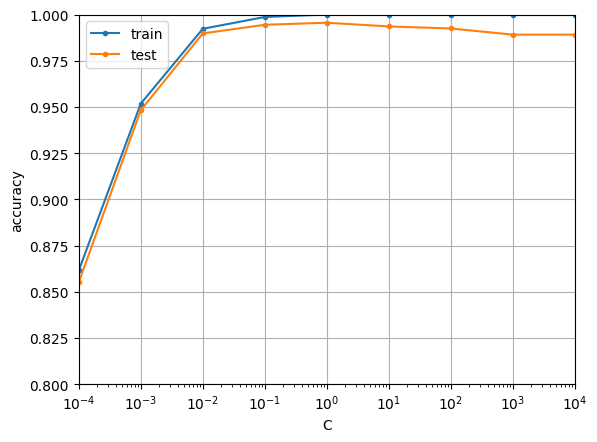

In [14]:
# Implement. Do not change the name or signature of these functions.
def evaluate_LR(X, y, C):
    """ Evaluate a Logistic Regression model with cross-validation on the provided image data.
    Keyword arguments:
    X -- the data for training and testing
    y -- the correct output values
    C -- the regularization constant

    Returns: a dictionary with the mean train and test score, e.g. {"train": 0.9, "test": 0.95}
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import cross_validate, StratifiedKFold
    import numpy as _np

    clf = LogisticRegression(C=C, solver='lbfgs')
    cv = StratifiedKFold(n_splits=5)
    scores = cross_validate(clf, X, y, cv=cv, scoring='accuracy', return_train_score=True)
    return {"train": float(_np.mean(scores['train_score'])), "test": float(_np.mean(scores['test_score']))}

def plot_curve(X,y,train_size):
    """ Plots the train and test accuracy of logistic regression on a
    subsample of the given data for different amounts of regularization.
    X          -- the data for training and testing
    y          -- the correct labels
    train_size -- the proportion of the data used for training and testing, between 0.0 and 1.0.

    Returns: a plot as described above, with C on the x-axis and accuracy on
    the y-axis.
    """
    import numpy as _np
    from sklearn.model_selection import train_test_split

    X_sub, _, y_sub, _ = train_test_split(X, y, train_size=train_size, stratify=y, random_state=0)

    Cs = _np.logspace(-4, 4, num=9)

    plot_live(X_sub, y_sub, evaluate_LR, 'C', Cs, scale='log', ylim=(.8,1), ylabel='accuracy')

plot_curve(X,y,0.25)

In [15]:
validation.signature_unchanged(evaluate_LR)

In [16]:
validation.signature_unchanged(plot_curve)

### Question 1.2: Interpretation (1 point)
Interpret the graph. Indicate which of the following answers are correct. Run additional tests if needed.

- 'A': Setting C=1e-4 causes the model to underfit
- 'B': Setting C=1e-4 causes the model to overfit
- 'C': Setting C=1e4 causes the model to underfit
- 'D': Setting C=1e4 causes the model to overfit
- 'E': Any value for C higher than 10 is fine (close to optimal)
- 'F': None of these is correct

Enter the correct letter(s) in value `q_1_2` in the code. They may be separated by commas (e.g. `'A,B,C'`) if multiple answers are correct.



In [ ]:
# Fill in the correct answer. Don't change the name of the variable
q_1_2 = 'A,D'

### Question 1.3: Evaluation on held-out data (1 point)
Implement the `evaluate_test` function that train a Logistic Regression model with C=0.1 on the given training set, and correctly evaluates it on the evaluation set.

*NOTE: This is the first exercise in which you should use the evaluation set.*

In [18]:
def evaluate_test(X_train, y_train, X_eval, y_eval):
    """ Evaluate a Logistic Regression model
    X_train -- the training data
    y_train -- the training labels
    X_eval  -- the evaluation (test) data
    y_eval  -- the evaluation (test) labels

    Returns: the evaluation score (accuracy) of the optimal model trained on pixel data
    """
    from sklearn.linear_model import LogisticRegression

    # Train with the specified C=0.1 as required
    clf = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000)
    clf.fit(X_train, y_train)

    return clf.score(X_eval, y_eval)

# Calling the functions. Don't change these calls
pixel_lr_score = evaluate_test(X, y, X_eval, y_eval)
embedding_lr_score = evaluate_test(X_embedded, y, X_eval_embedded, y_eval)

In [19]:
validation.signature_unchanged(evaluate_test)

In [20]:
print("Pixel representation score:",pixel_lr_score)
print("Embedding representation score:",embedding_lr_score)

Pixel representation score: 0.9955555555555555
Embedding representation score: 0.9644444444444444


Interpret the results. Indicate which of the following answers are correct.

- 'A': The pixel representation works much better than the deep learning embedding. This is because the deep learning embedding was pretrained on images from the internet and that's very different than the characters here.
- 'B': The pixel representation works much better since it's a lot more concise representation of the data.
- 'C': The deep learning embedding representation works much better since it represents general components of images (e.g. lines and curves) and complex combinations thereof.
- 'D': The deep learning embedding representation works much better since it was pretrained on ancient Japanese characters (hence, it's cheating).
- 'E': None of these is correct

Enter the correct letter(s) in value `q_1_3` in the code. They may be separated by commas (e.g. `'A,B,C'`) if multiple answers are correct.

In [21]:
# Fill in the correct answer. Don't change the name of the variable
q_1_3 = 'A'

### Question 1.4: Few-shot learning (1 point)
Few-shot learning is a branch of machine learning where we need to learn from very few examples.
Implement the method `few_shot_learning`, which is identical to `evaluate_test`, only it uses only 1% of the training data, about 17 images per character (and all of the evaluation data).

*NOTE: This is the last exercise in which you should use the evaluation set.*

In [22]:
# Implement
def few_shot_learning(X_train, y_train, X_eval, y_eval):
    """ Evaluate a Logistic Regression model
    X_train -- the training data
    y_train -- the training labels
    X_eval  -- the evaluation (test) data
    y_eval  -- the evaluation (test) labels

    Returns: the evaluation score (accuracy) of the optimal model trained on pixel data
    """
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split

    X_small, _, y_small, _ = train_test_split(X_train, y_train, train_size=0.01, stratify=y_train, random_state=0)

    clf = LogisticRegression(C=0.1, solver='lbfgs', max_iter=1000)
    clf.fit(X_small, y_small)

    return clf.score(X_eval, y_eval)

# Calling the functions. Don't change these calls
pixel_few_shot = few_shot_learning(X, y, X_eval, y_eval)
embedding_few_shot = few_shot_learning(X_embedded, y, X_eval_embedded, y_eval)

In [23]:
validation.signature_unchanged(few_shot_learning)

In [24]:
print("Pixel representation score:",pixel_few_shot)
print("Embedding representation score:",embedding_few_shot)

Pixel representation score: 0.9526111111111111
Embedding representation score: 0.6725


Interpret the results. Indicate which of the following answers are correct.

- 'A': The pixel representation now work much better than the deep learning embedding. The embeddings is too high-dimensional so you need more data to train the linear classifier well.
- 'B': The deep learning embedding representation is still equally good as before. This is because everything we need to know is in the embedding and we can learn from very few examples.
- 'C': Both models perform worse now. The embedding is too general, and we still need sufficient training data for the classifier (logistic regression) to allow it to learn a mapping from the embeddings to the character classes.
- 'D': None of these is correct

Enter the correct letter(s) in value `q_1_3` in the code. They may be separated by commas (e.g. `'A,B,C'`) if multiple answers are correct.

In [25]:
# Fill in the correct answer. Don't change the name of the variable
q_1_4 = 'A,C'

## Question 2

### Question 2.1: Model inspection (1 point)
Implement a function `plot_character_coefficients` that trains 3 logistic regression models on the pixel representation (not the embeddings), one trained with C=1e-4, one with C=1e-1, and one with C=1e4. For all models, use Stochastic Average Gradient Descent with at least 100 iterations. Also evaluate each model by using 75% of the data for training and the rest for testing.

To interpret whether the model has learned something useful, we will now plot the coefficients of these three models. Remember that Logistic Regression is a binary classifier, and you can assume (see the note below) that a one-vs-rest-like approach is used for multi-class problems, hence the n-th set of coefficients in the model belong to the submodel that separates the n-th class from the rest. To plot these coefficients, you'll need to reshape them into a 28x28 matrix and then plot that (e.g. use `imshow` as in previous examples, and use an intuitive [colormap](https://matplotlib.org/stable/users/explain/colors/colormaps.html) to represent low and high values, like 'plasma').

Your function is given a character `character`. First, plot an example of this character (any will do). Then, plot the coefficients of the model that separates the character from the other characters. Repeat 3 times for the different C values. It is also given a `penalty` parameter which allows to set the regularizer to be switched

Hence, you should return four plots: one character plot and three coeficients plots, and they should appear next to each other (not below each other). Add the C-value and test accuracy to the title of the three coefficient plots. Evaluate the test accuracy with a simple 75-25 train-test split).

Run `plot_character_coefficients` for character `two`.

Note: Scikit-learn actually uses [a more sophisticated approach](https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_multinomial.html#sphx-glr-auto-examples-linear-model-plot-logistic-multinomial-py) here than simple one-vs-all. It uses the fact that Logistic Regression predicts probabilities, and hence the probabilities of each class are taken into account (in a softmax function). It will still produce one model per class.

Started training for C=0.0001: 1771950881.3869567
Training ended: 1771950891.4373753
Started training for C=0.1: 1771950891.4705844
Training ended: 1771950946.488112
Started training for C=10000.0: 1771950946.520708
Training ended: 1771951001.6874778


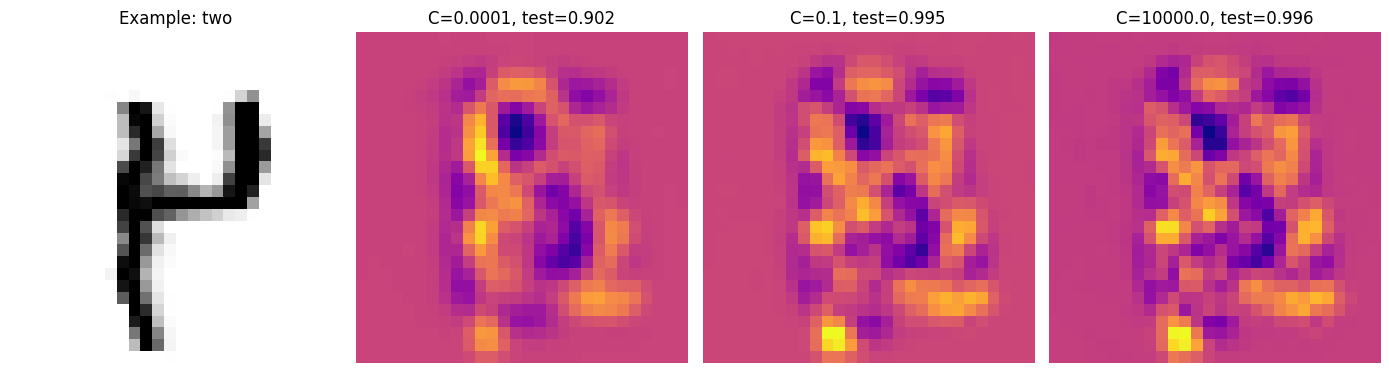

In [26]:
# Implement. Do not change the name or signature of this function.
def plot_character_coefficients(X, y, character, penalty='l2'):
    """ Plots 28x28 heatmaps showing the coefficients of three Logistic
    Regression models, each with different amounts of regularization values.
    X -- the data for training and testing
    y -- the correct labels
    character -- the character to plot
    penalty -- the penalty to use, 'l2' by default

    Returns: 4 plots, as described above.
    """
    import numpy as _np
    import matplotlib.pyplot as _plt
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import train_test_split
    
    # Find numeric label corresponding to the requested character
    label_num = next(k for k, v in lang_classes.items() if v == character)

    # Pick an example index of the requested character to display
    idx = _np.where(y.astype(int) == label_num)[0][0]
    ex_row = X.iloc[idx]

    # Prepare subplots: 1 example + 3 coefficient heatmaps side-by-side
    fig, axes = _plt.subplots(1, 4, figsize=(14,4))

    # Plot example image
    axes[0].imshow(ex_row.values.reshape(28,28), cmap='gray_r')
    axes[0].set_title(f'Example: {character}')
    axes[0].axis('off')

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, stratify=y, random_state=0)

    Cs = [1e-4, 1e-1, 1e4]
    for i, C in enumerate(Cs, start=1):
        # Create logistic regression using SAG solver for stochastic average gradient behaviour
        clf = LogisticRegression(C=C, penalty=penalty, solver='saga', random_state=0, n_jobs=-1)
        print(f"Started training for {C=}:", time.time())
        clf.fit(X_train, y_train)
        print("Training ended:", time.time())
        test_acc = clf.score(X_test, y_test)

        # Plot coefficients for label_num
        coef = clf.coef_[label_num].reshape(28, 28)

        im = axes[i].imshow(coef, cmap='plasma')
        axes[i].set_title(f'C={C}, test={test_acc:.3f}')
        axes[i].axis('off')

    _plt.tight_layout()
    _plt.show()

plot_character_coefficients(X, y, 'two')

In [27]:
validation.signature_unchanged(plot_character_coefficients)

### Question 2.2: Sparse models (1 point)
Plot the coefficient again, but this time use a sparse logistic regression model. Keep everything else the same as in the previous question.

Started training for C=0.0001: 1771951002.3969579
Training ended: 1771951003.197813
Started training for C=0.1: 1771951003.2490344
Training ended: 1771951093.2644422
Started training for C=10000.0: 1771951093.3358357
Training ended: 1771951240.8759654


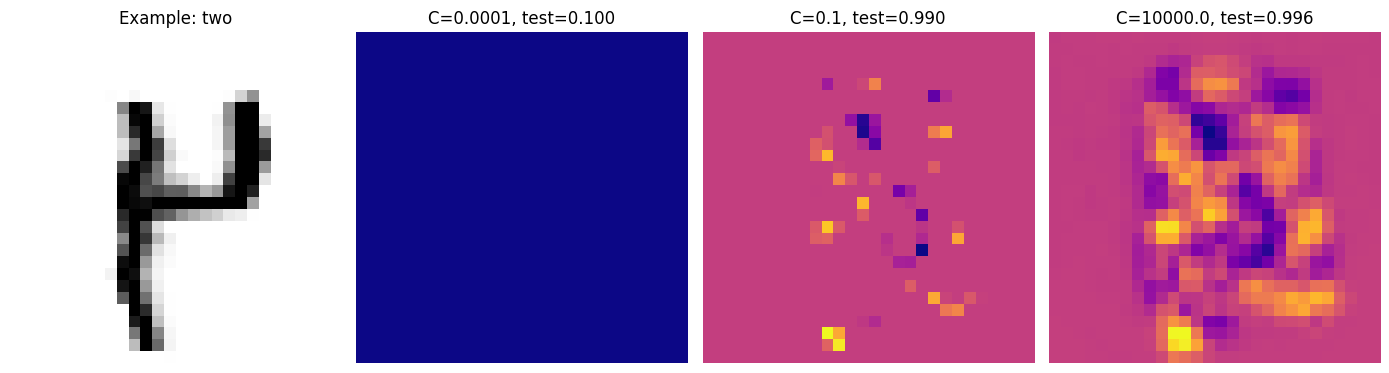

In [28]:
# Implement. Do not change the name or signature of this function.
def plot_sparse_character_coefficients(X, y, character):
    plot_character_coefficients(X, y, character, penalty='l1')

plot_sparse_character_coefficients(X, y, 'two')

In [29]:
validation.signature_unchanged(plot_sparse_character_coefficients)

### Question 2.3: Interpretation (1 points)
Interpret the graphs. Indicate which of the following answers are correct.

- 'A': For C=1e-4, the dense model is performing well. It clearly captures the shape of the character 'two' in its weights. Hence, it's paying attention to the right pixels.
- 'B': For C=1e-4, the dense model is underfitting. It can only capture one way of writing the character.
- 'C': For C=1e-4, the dense model is overfitting to a particular way of writing character 'two'.
- 'D': For C=0.1, the dense model is well-balanced, paying attention to different pixels to capture different ways of writing the character 'two'.
- 'E': For C=0.1, the weight are entirely random, hence it's clearly overfitting.
- 'F': For C=1e4, the dense model is well-balanced, paying attention to different pixels to capture different ways of writing the character 'two'.
- 'G': For C=1e4, the weight for the dense model are quite random and the model is likely overfitting.
- 'H': The sparse model with C=0.1 is a lot faster to train than the dense model with C=0.1.
- 'I': The sparse model with C=1e-4 ignores about half of the pixels but can still accurately predict the characters.
- 'J': The sparse model with C=0.1 ignores about half of the pixels but can still accurately predict the characters.
- 'K': The sparse model with C=1e4 ignores about half of the pixels but can still accurately predict the characters.
- 'L': The sparse model with C=1e4 isn't very sparse at all. It has about the same weights as the dense model
- 'M': Models with very high C values (more penalized) take much longer to train than models very low C values (more relaxed).
- 'N': Models with very high C values (more penalized) are much faster to train than models very low C values (more relaxed).
- 'O': None of these is correct

Enter the correct letter(s) in value `q_2_3` in the code. They may be separated by commas (e.g. `'A,B,C'`) if multiple answers are correct.

In [ ]:
# Fill in the correct answer(s). Don't change the name of the variable
q_2_3 = 'A,D,G,J,L,M'

## Question 3

### Question 3.1: Learning curve analysis (1 points)

Implement a method `learning_curve` that trains a Logistic Regression model trained using Stochastic Gradient Descent (SGD) on mini-batches of data and returns the training and validation accuracies after every batch. The curve that plots the model's scores after every new batch of training data is called a learning curve. Your implementation must also allow cycling multiple times over the training datasets (one pass over the training data is called an _epoch_).

The method must first make a (single) stratified 80-20 split of the input data (with `random_state=0`), where 80% forms the training data and the other 20% the validation data. It will then cycle `n_epoch` times over the training data. Every cycle, it shuffles the data, ensuring every epoch has a different shuffle of the data, and then creates batches of training data, where each batch consists of `batch_size` training examples. It must then _incrementally_ train the Logistic Regression model on every batch, i.e. continue training the model instead of re-initializing it, and after every batch it must compute the accuracy on the entire training and validation set. After `n_epoch` passes have been computed, it returns `train_accuracies` and `val_accuracies`, both vectors with the training and validation scores after each batch, respectively.

You'll have to use the [SGD Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier) to be able to do this in sklearn. Carefully consider how to use it so that it is equivalent to a Logistic Regression model, and that the regularization parameter is called `alpha`. This is an incremental learner: you can simply use `partial_fit` instead of the default `fit` to train the model incrementally. [See here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html#sklearn.linear_model.SGDClassifier.partial_fit), and note that it requires the list of classes when first called. `SGDClassifier` also takes a hyperparameter `alpha` representing the regularization strength. For SGD you can use the `optimal` learning rate. This performs a kind of learning rate decay, starting with a larger learning rate and gradually making it smaller. With every batch, do a single optimization iteration. Use `random_state=0`.

To test the method and plot the result, we provide the simple `plot_learning_curves` method below. You must run the method on the entire (training) dataset, i.e. `X` and `y`. Use alpha=0.01 and run for 5 epochs.

Note: You'll have to implement most of this yourself. There is no handy method in sklearn that does this for you the way described here. However, we provide example code in `learning_curve_example` to show how to divide the data in batches and train SGD incrementally. Note that this code is very incomplete so you'll need to adapt it.



  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

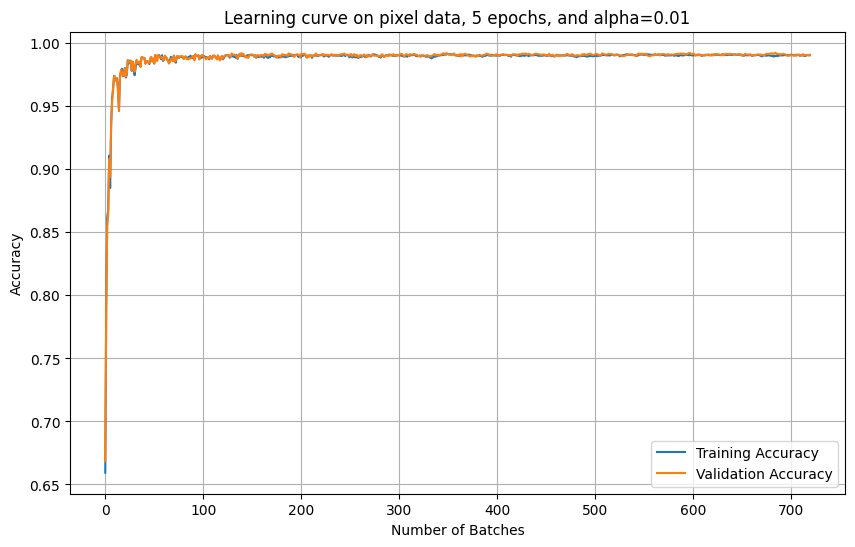

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

  0%|          | 0/144 [00:00<?, ?it/s]

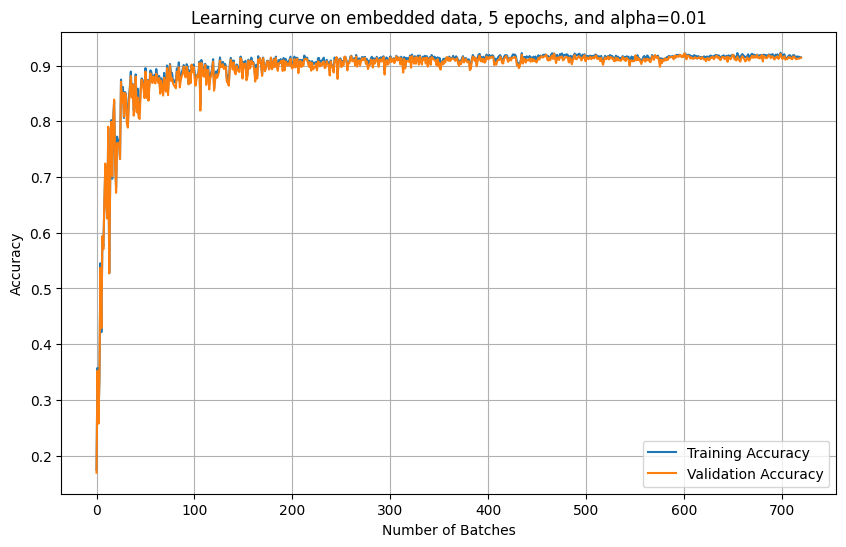

In [31]:
# Implement. Do not change the name or signature of this function.
def learning_curve(X, y, alpha=0.01, n_epochs=1, batch_size=100):
    """ Trains a Logistic Regression model incrementally using stochastic gradient descent and returns the learning curves.
    X -- the data for training and testing
    y -- the correct labels
    alpha -- the regularization hyperparameter
    n_epochs -- the number of epochs
    batch_size -- the batch size
    Returns: Two arrays, with the training accuracies and validation accuracies, respectively, in that order.
    """
    import numpy as _np
    from sklearn.linear_model import SGDClassifier
    from sklearn.model_selection import train_test_split
    from sklearn.utils import shuffle

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.20, stratify=y, random_state=0)
    
    clf = SGDClassifier(loss='log_loss', alpha=alpha, learning_rate='optimal', random_state=0)
    classes = _np.unique(y)
    
    train_accuracies = []
    val_accuracies = []
    
    for epoch in tqdm(range(n_epochs)):
        X_shf, y_shf = shuffle(X_train, y_train, random_state=epoch)
        
        for i in tqdm(range(0, len(X_shf), batch_size)):
            X_batch = X_shf[i : i + batch_size]
            y_batch = y_shf[i : i + batch_size]
            
            # Incremental training
            clf.partial_fit(X_batch, y_batch, classes=classes)
            
            train_accuracies.append(clf.score(X_train, y_train))
            val_accuracies.append(clf.score(X_val, y_val))
            
    return train_accuracies, val_accuracies

def plot_learning_curves(train_accuracies, val_accuracies, title='Learning Curve Across Epochs'):
    """ Plots the given learning curves. """
    if len(train_accuracies) > 0:
        plt.figure(figsize=(10, 6))
        plt.plot(train_accuracies, label='Training Accuracy')
        plt.plot(val_accuracies, label='Validation Accuracy')
        plt.xlabel('Number of Batches')
        plt.ylabel('Accuracy')
        plt.title(title)
        plt.grid(True)
        plt.legend()
        plt.show()

plot_learning_curves(*learning_curve(X, y, alpha=0.01, n_epochs=5), title="Learning curve on pixel data, 5 epochs, and alpha=0.01")
plot_learning_curves(*learning_curve(X_embedded, y, alpha=0.01, n_epochs=5), title="Learning curve on embedded data, 5 epochs, and alpha=0.01")

### Question 3.2: Interpretation (1 points)

Interpret the graphs. Indicate which of the following answers are correct.  
*Note*: Feel free to run additional experiments if you feel that you need them.

- 'A': The SGD approach performs much better than the Logistic Regression model used in Question 1, given the same training data.
- 'B': The SGD approach performs about the same as the Logistic Regression model used in Question 1, given the same training data (if there is a difference it is less than 5% accuracy).
- 'C': The learning curve on the embedded data is steeper (learns faster). E.g. after 50 batches it has already surpassed the learning curve of the pixel data.
- 'D': The learning curve on the embedded data matches the one on the pixel data. Only in the last epoch does it surpass the learning curve of the pixel data.
- 'E': The learning curves for the validation accuracy go down. That means that both models are overfitting.
- 'F': Both learning curves flatten out after a few epochs. It's not worth training for much longer.
- 'G': None of these are correct

In [32]:
# Fill in the correct answer. Don't change the name of the variable
q_3_2 = 'B,F'

## Question 4 
### Question 4.1 (1 points)

Archeologists (surprisingly) found an electronic keypad to an ancient temple entrance, that had a sequence of numbers. They need your help to uncover the meaning of the missing characters and expand our knowledge on early Ethopian literature.

They sent us pictures of the missing characters in the form of 8, 28x28 numpy arrays (because why not). These are provided in your repository.

In [33]:
# Note: if you run this on colab, copy this file into your Colab environment

code = pd.DataFrame(np.load('mysterychar.npy'))

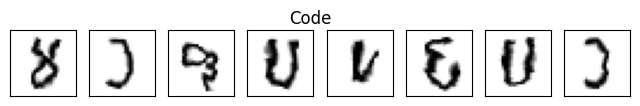

In [34]:
plot_examples(code, None, row_length=8, title="Code")

Use the best model that you trained on the embeddings in question 1 to classify these images. Implement a small method `predict_characters` that prints the right classes (e.g. 'one') given the character values. Note that you may have to embed the new characters in order to do so (this will be fast since it's only a few characters).

Once you have translated them into modern English, translate them to English and type the code in the variables q_4_code. The answers should be in the form "five six seven ...". You do not need to convert it to numbers

In [35]:
# code already scaled
print(code.min().min())
print(code.max().max())

0.0
1.0


In [36]:
# Implement. Do not change the name or signature of this function.
def predict_characters(X, y, X_test):
    """ Print the class names for all the images in X.
    X -- the data for training and testing
    y -- the correct labels
    X_test -- the new input images as 1D arrays

    Returns: an array with the classified characters
    """
    from sklearn.linear_model import LogisticRegression

    model = LogisticRegression(C=0.01, solver='lbfgs')
    model.fit(X, y)

    preds = model.predict(X_test)
    
    return [lang_classes[int(p)] for p in preds]


characters = predict_characters(X, y, code)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [37]:
print(" ".join(characters))

four seven three nine seven two nine seven


In [38]:
# Fill in the correct meaning (ensure there are no spaces at the start or at the end:)
q_4_code = "four seven three nine seven two nine seven"